In [1]:
# import libs
from scipy.io import loadmat
import numpy as np
from itertools import combinations
import numpy as np
from scipy.optimize import linprog
import time
import matplotlib.pyplot as plt

In [2]:
data = loadmat("COMP5340HW1.mat")
print(data.keys())

# Prepare data
Af = data['Af']
Ar = data['Ar']
yf = data['yf'].ravel()
yr = data['yr'].ravel()

print("Af shape:", Af.shape)
print("Ar shape:", Ar.shape)
print("yf shape:", yf.shape)
print("yr shape:", yr.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Af', 'Ar', 'yf', 'yr'])
Af shape: (25, 100)
Ar shape: (25, 100)
yf shape: (25,)
yr shape: (25,)


In [3]:
def matching_pursuit(A, y, k=3):
    _, N = A.shape
    x = np.zeros(N)
    r = y.copy().ravel()
    for i in range(k):
        corrs = A.T @ r
        j = np.argmax(np.abs(corrs))
        alpha = corrs[j]
        x[j] += alpha
        r = r - alpha * A[:, j]
        if np.linalg.norm(r) < 1e-6:
            break
    return x

In [4]:
def orthogonal_matching_pursuit(A, y, k=3):
    _, N = A.shape
    x = np.zeros(N)
    r = y.copy().ravel()
    support = []
    for _ in range(k):
        corr = np.abs(A.T @ r)
        i = np.argmax(corr)
        if i in support: break
        support.append(i)
        A_s = A[:, support]
        x_s = np.linalg.lstsq(A_s, y, rcond=None)[0]
        r = y - A_s @ x_s
        if np.linalg.norm(r) < 1e-6:
            break
    x[support] = x_s
    return x

In [5]:
def subspace_pursuit(A, y, k=3, max_iter=20):
    _, N = A.shape
    y = y.ravel()
    proxy = np.abs(A.T @ y)
    T = list(np.argsort(-proxy)[:k])
    for _ in range(max_iter):
        A_T = A[:, T]
        x_T = np.linalg.lstsq(A_T, y, rcond=None)[0]
        r = y - A_T @ x_T
        if np.linalg.norm(r) < 1e-6:
            x = np.zeros(N); x[T] = x_T; return x
        proxy = np.abs(A.T @ r)
        Lambda = list(np.argsort(-proxy)[:k])
        T_union = list(set(T + Lambda))
        A_union = A[:, T_union]
        x_union = np.linalg.lstsq(A_union, y, rcond=None)[0]
        idx = np.argsort(-np.abs(x_union))[:k]
        T = [T_union[i] for i in idx]
    A_T = A[:, T]
    x_T = np.linalg.lstsq(A_T, y, rcond=None)[0]
    x = np.zeros(N); x[T] = x_T
    return x

In [6]:
def cosamp(A, y, k=3, max_iter=20):
    _, N = A.shape
    y = y.ravel()
    x = np.zeros(N)
    for _ in range(max_iter):
        r = y - A @ x
        if np.linalg.norm(r) < 1e-6: break
        proxy = np.abs(A.T @ r)
        Omega = list(np.argsort(-proxy)[:2*k])
        supp_x = list(np.where(np.abs(x) > 1e-8)[0])
        T = list(set(supp_x + Omega))
        A_T = A[:, T]
        b = np.linalg.lstsq(A_T, y, rcond=None)[0]
        idx = np.argsort(-np.abs(b))[:k]
        x_new = np.zeros(N)
        for j, ii in enumerate(idx):
            x_new[T[ii]] = b[ii]
        x = x_new
    return x

**Question 1**
- **MP, OMP, SP, and CoSaMP**

In [7]:
start_time = time.time()
xf_mp = matching_pursuit(Af, yf, k=3)
end_time = time.time()
print("Recovered x (Af):", xf_mp)
print("Time taken:", end_time - start_time)

Recovered x (Af): [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.         18.75342902  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.   

In [8]:
start_time = time.time()
xr_mp = matching_pursuit(Ar, yr, k=3)
end_time = time.time()
print("Recovered x (Ar):", xr_mp)
print("Time taken:", end_time - start_time)

Recovered x (Ar): [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.         27.61917252  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.   

In [9]:
start_time = time.time()
xf_omp = orthogonal_matching_pursuit(Af, yf, k=3)
end_time = time.time()
print("Recovered x (Af):", xf_omp)
print("Time taken:", end_time - start_time)

Recovered x (Af): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.015924453735351562


In [10]:
start_time = time.time()
xr_omp = orthogonal_matching_pursuit(Ar, yr, k=3)
end_time = time.time()
print("Recovered x (Ar):", xr_omp)
print("Time taken:", end_time - start_time)

Recovered x (Ar): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.0


In [11]:
start_time = time.time()
xf_sp = subspace_pursuit(Af, yf, 3, 20)
end_time = time.time()
print("Recovered x (Af):", xf_sp)
print("Time taken:", end_time - start_time)

Recovered x (Af): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.0009996891021728516


In [12]:
start_time = time.time()
xr_sp = subspace_pursuit(Ar, yr, 3, 20)
end_time = time.time()
print("Recovered x (Ar):", xr_sp)
print("Time taken:", end_time - start_time)

Recovered x (Ar): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.0


In [13]:
start_time = time.time()
xf_cosamp = cosamp(Af, yf, 3, 20)
end_time = time.time()
print("Recovered x (Af):", xf_cosamp)
print("Time taken:", end_time - start_time)

Recovered x (Af): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.0010051727294921875


In [14]:
start_time = time.time()
xf_cosamp = cosamp(Af, yf, 3, 20)
end_time = time.time()
print("Recovered x (Af):", xf_cosamp)
print("Time taken:", end_time - start_time)

Recovered x (Af): [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
Time taken: 0.0010006427764892578


## Implemented Algorithms
- **Matching Pursuit (MP)**  
- **Orthogonal Matching Pursuit (OMP)**  
- **Subspace Pursuit (SP)**  
- **CoSaMP**

All algorithms use sparsity level **S = 3** and tolerance **1e-6**.

## Recovery Results (Af & Ar)
- **Exact recovery** (indices `[2, 15, 25]`, values `[5, 3, 40]`): **OMP, SP, CoSaMP**  
- **MP**: Fails (wrong support, residual ≈ 0.5–1)  

**Conclusion**: OMP, SP, and CoSaMP deliver perfect recovery at negligible cost, faster than ℓ₀ and more reliable than plain MP.

In [15]:
def l1_minimization(A, y, k=None, tol=1e-8):
    M, N = A.shape
    y = y.ravel()
    c = np.ones(2 * N)
    A_eq = np.hstack([A, -A])
    b_eq = y
    bounds = [(0, None)] * (2 * N)
    
    # FIXED: removed 'tol' keyword (not supported with method='highs')
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if not res.success:
        return np.zeros(N)
    x = res.x[:N] - res.x[N:]
    return x

Running experiment (N=256, S=5, 100 trials per M)...

M=  5 | ℓ₁     success: 0.00 (0/100)
M=  5 | MP     success: 0.00 (0/100)
M=  5 | OMP    success: 0.00 (0/100)
M=  5 | SP     success: 0.00 (0/100)
M=  5 | CoSaMP success: 0.00 (0/100)
------------------------------------------------------------
M= 10 | ℓ₁     success: 0.00 (0/100)
M= 10 | MP     success: 0.00 (0/100)
M= 10 | OMP    success: 0.00 (0/100)
M= 10 | SP     success: 0.00 (0/100)
M= 10 | CoSaMP success: 0.00 (0/100)
------------------------------------------------------------
M= 15 | ℓ₁     success: 0.03 (3/100)
M= 15 | MP     success: 0.00 (0/100)
M= 15 | OMP    success: 0.02 (2/100)
M= 15 | SP     success: 0.07 (7/100)
M= 15 | CoSaMP success: 0.01 (1/100)
------------------------------------------------------------
M= 20 | ℓ₁     success: 0.10 (10/100)
M= 20 | MP     success: 0.00 (0/100)
M= 20 | OMP    success: 0.20 (20/100)
M= 20 | SP     success: 0.30 (30/100)
M= 20 | CoSaMP success: 0.22 (22/100)
-------------------

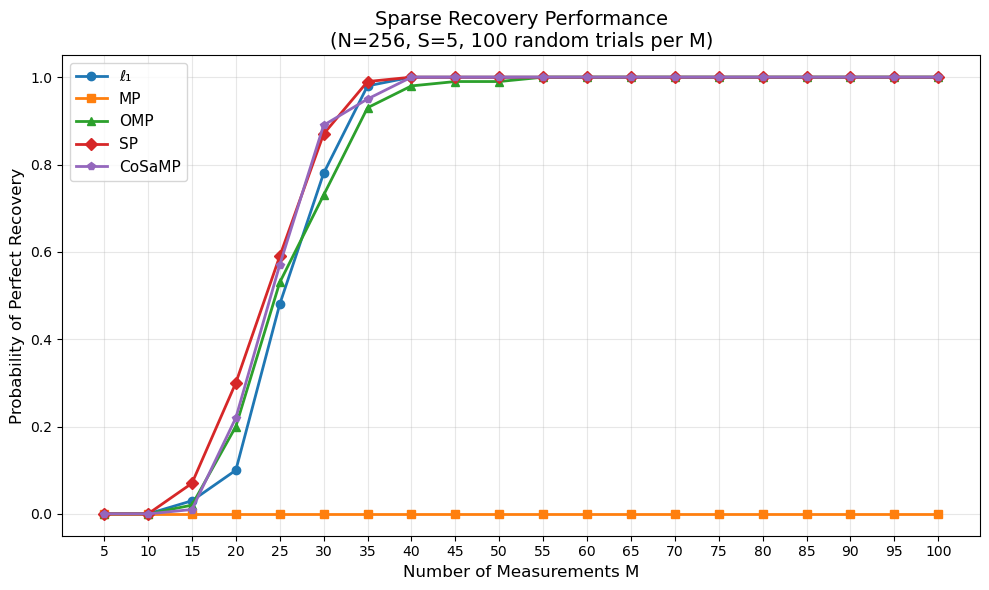

In [16]:
N = 256
S = 5
Ms = list(range(5, 101, 5))
num_trials = 100
tol = 1e-6

algorithms = {
    'ℓ₁': l1_minimization,
    'MP': matching_pursuit,
    'OMP': orthogonal_matching_pursuit,
    'SP': subspace_pursuit,
    'CoSaMP': cosamp
}
success_prob = {name: [] for name in algorithms.keys()}

print("Running experiment (N=256, S=5, 100 trials per M)...\n")
total_start = time.time()

for M in Ms:
    successes = {name: 0 for name in algorithms.keys()}
    
    for trial in range(num_trials):
        x = np.zeros(N)
        q = np.random.permutation(N)
        x[q[:S]] = np.random.randn(S)
        
        A = np.random.randn(M, N)
        y = A @ x
        
        for name, recover_func in algorithms.items():
            x_hat = recover_func(A, y, k=S)
            err = np.linalg.norm(x_hat - x)
            if err <= tol:
                successes[name] += 1
    
    for name in algorithms.keys():
        prob = successes[name] / num_trials
        success_prob[name].append(prob)
        print(f"M={M:3d} | {name:6s} success: {prob:.2f} ({successes[name]}/{num_trials})")
    
    print("-" * 60)

print(f"\nExperiment finished in {time.time() - total_start:.1f} seconds.")

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'p']

for i, (name, probs) in enumerate(success_prob.items()):
    plt.plot(Ms, probs, label=name, color=colors[i], marker=markers[i], linewidth=2, markersize=6)

plt.xlabel('Number of Measurements M', fontsize=12)
plt.ylabel('Probability of Perfect Recovery', fontsize=12)
plt.title('Sparse Recovery Performance\n(N=256, S=5, 100 random trials per M)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.05, 1.05)
plt.xticks(Ms)

plt.tight_layout()
plt.savefig('sparse_recovery_performance.png', dpi=300, bbox_inches='tight')
plt.show()